In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load the dataset
df = pd.read_csv('latin_america_gdp_growth.csv')
# Display the first few rows (as detailed in your proposal's Table 1)
display(df.head())
# Print data information to check for missing values (like YR1960)
print(df.info())

,economy,Country,YR1960,YR1961,YR1962,YR1963,YR1964,YR1965,YR1966,YR1967,...,YR2015,YR2016,YR2017,YR2018,YR2019,YR2020,YR2021,YR2022,YR2023,YR2024
0,VEN,"Venezuela, RB",NaN,3.192519,8.532934,3.900951,11.129345,4.162867,1.510250,2.833869,...,-6.221371,-17.040335,-15.671409,-19.655342,-27.657968,-29.998570,0.955433,8.000913,4.001686,5.300000
1,URY,Uruguay,NaN,2.493038,-1.574549,0.170459,2.440521,1.045604,3.062856,-3.656834,...,0.370741,1.689798,1.740376,0.164778,0.928351,-7.357327,5.844273,4.486227,0.742129,3.108255
2,PER,Peru,NaN,7.347096,10.035293,4.328250,6.547868,5.621733,8.238920,3.852564,...,3.252245,3.953319,2.518835,3.969351,2.240632,-10.933307,13.362624,2.809034,-0.403242,3.303941
3,PRY,Paraguay,NaN,6.900286,3.300259,4.710291,4.212477,6.167975,1.991503,9.150367,...,2.957152,4.268026,4.810079,3.204250,-0.401855,-0.819785,4.016737,0.176038,4.999228,4.249960
4,PAN,Panama,NaN,10.926595,8.244737,8.538789,4.432130,9.160036,7.581402,8.552931,...,5.266917,4.571967,5.744059,3.918198,3.103068,-17.821230,16.467125,11.038548,7.166329,2.747885


<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 67 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   economy  20 non-null     str    
 1   Country  20 non-null     str    
 2   YR1960   0 non-null      float64
 3   YR1961   18 non-null     float64
 4   YR1962   18 non-null     float64
 5   YR1963   18 non-null     float64
 6   YR1964   18 non-null     float64
 7   YR1965   18 non-null     float64
 8   YR1966   19 non-null     float64
 9   YR1967   19 non-null     float64
 10  YR1968   19 non-null     float64
 11  YR1969   19 non-null     float64
 12  YR1970   19 non-null     float64
 13  YR1971   20 non-null     float64
 14  YR1972   20 non-null     float64
 15  YR1973   20 non-null     float64
 16  YR1974   20 non-null     float64
 17  YR1975   20 non-null     float64
 18  YR1976   20 non-null     float64
 19  YR1977   20 non-null     float64
 20  YR1978   20 non-null     float64
 21  YR1979   20 non-null     floa

## Data Preprocessing and Exploratory Data Analysis. (EDA)

### 1. Reshaping and Handling Missing Data

We will transpose the dataset so that the rows represent the chronological timeline. Then, we will drop the year 1960 since it has no values for each country.

In [2]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# 2. Drop the 1960 column completely
if 'YR1960' in df.columns:
    df = df.drop(columns=['YR1960'])
    print("Successfully dropped the YR1960 column.")
# 3. Reshape: Set 'ISO' as index, drop 'Country' name, and transpose
ts_data = df.drop(columns=['Country']).set_index('economy').T
# 4. Clean the index: Convert 'YR1961' onwards to a proper DateTime index
ts_data.index = ts_data.index.str.replace('YR', '').astype(int)
ts_data.index = pd.to_datetime(ts_data.index, format='%Y')
# Verify we have a clean dataset with no missing values
ts_data_clean = ts_data.interpolate(method='time').bfill()
print(f"Remaining Missing Values: {ts_data_clean.isna().sum().sum()}")
print(f"New Time Series Start Year: {ts_data_clean.index.min().year}")
display(ts_data_clean.head())

Successfully dropped the YR1960 column.
Remaining Missing Values: 0
New Time Series Start Year: 1961


economy,VEN,URY,PER,PRY,PAN,NIC,MEX,HND,HTI,GTM,SLV,ECU,DOM,CUB,CRI,COL,CHL,BRA,BOL,ARG
1961-01-01,3.192519,2.493038,7.347096,6.900286,10.926595,7.497743,5.000000,1.663565,-2.931980,4.298518,7.161138,5.124415,-2.313249,8.583859,1.879277,5.089217,5.519611,8.6,2.089296,5.427843
1962-01-01,8.532934,-1.574549,10.035293,3.300259,8.244737,10.890798,4.664415,2.185237,7.887576,3.536501,7.161138,4.919147,17.047241,8.583859,5.442391,5.411890,3.930785,6.6,5.578918,-0.852022
1963-01-01,3.900951,0.170459,4.328250,4.710291,8.538789,10.865479,8.106887,1.268279,-1.892793,9.541044,7.161138,2.106368,6.502903,8.583859,6.898923,3.286708,5.686672,0.6,6.797626,-5.308197
1964-01-01,11.129345,2.440521,6.547868,4.212477,4.432130,11.698479,11.905481,1.547156,-1.647357,4.632992,7.161138,7.407245,6.764865,8.583859,3.659048,6.166941,2.461134,3.4,3.956597,10.130298
1965-01-01,4.162867,1.045604,5.621733,6.167975,9.160036,9.525156,7.100000,2.583336,2.161798,4.361769,7.161138,3.275082,-12.481834,8.583859,8.190528,3.600011,0.670839,2.4,4.913442,10.569433


### 2. Exploratory Data Analysis (EDA)

Let's visualize the economic trajectories of a few major economies. This will help us visually spot periods of high volatility (like the 1980s debt crisis or the 2020 pandemic).

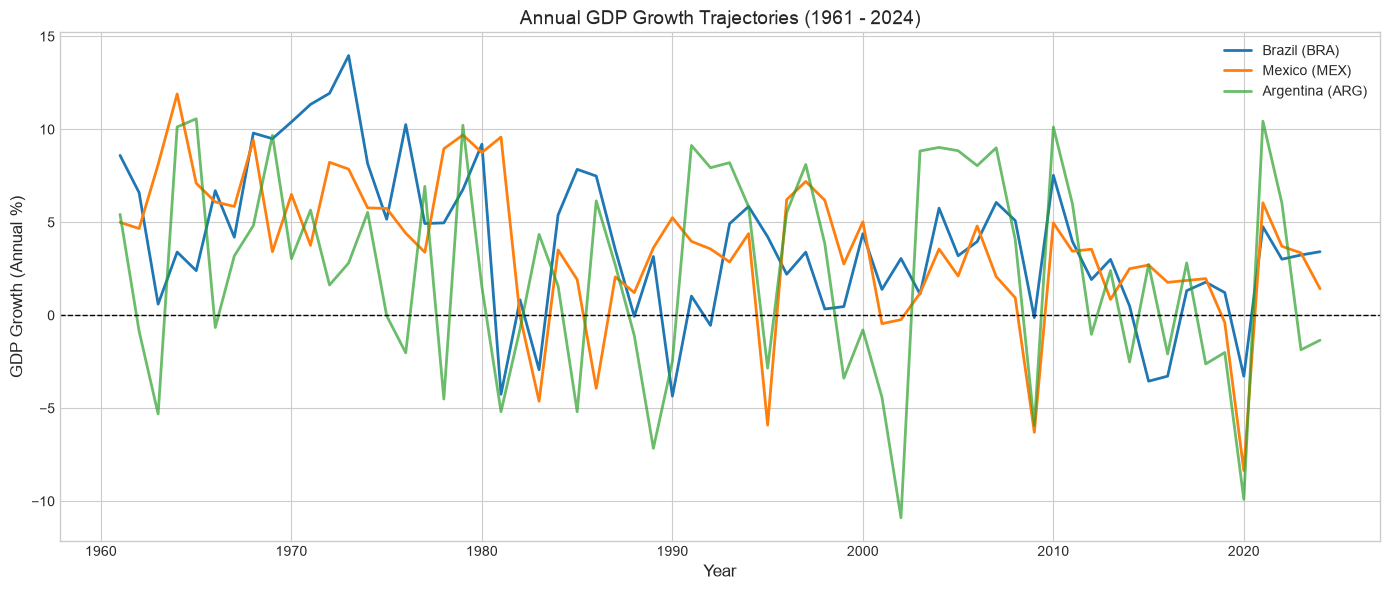

In [3]:
# Set a consistent plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 6))
# Plotting Brazil, Mexico, and Argentina as examples
plt.plot(ts_data_clean.index, ts_data_clean['BRA'], label='Brazil (BRA)', linewidth=2)
plt.plot(ts_data_clean.index, ts_data_clean['MEX'], label='Mexico (MEX)', linewidth=2)
plt.plot(ts_data_clean.index, ts_data_clean['ARG'], label='Argentina (ARG)', linewidth=2, alpha=0.7)
plt.title('Annual GDP Growth Trajectories (1961 - 2024)', fontsize=14)
plt.ylabel('GDP Growth (Annual %)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.axhline(0, color='black', linestyle='--', linewidth=1) # Zero-growth baseline
plt.legend()
plt.tight_layout()
plt.show()

### 3. Stationarity Testing (ADF Test)

ARIMA models require the time series to be stationary (constant mean and variance over time). We will loop through all 20 countries and run the Augmented Dickey-Fuller (ADF) test.

- If the p-value is <0.05, the series is stationary (d=0).
- If the p-value is >0.05, the series has a unit root and requires differencing (d=1).

In [4]:
def check_stationarity(timeseries, country_code):
    """Runs ADF test and returns integration order needed."""
    result = adfuller(timeseries)
    p_value = result[1]

    if p_value > 0.05:
        print(f"[{country_code}] p-value: {p_value:.4f} -> Non-Stationary (Requires differencing: d=1)")
        return 1
    else:
        print(f"[{country_code}] p-value: {p_value:.4f} -> Stationary (d=0)")
        return 0
# Dictionary to store the required differencing order for the ARIMA phase
integration_orders = {}
print("--- Augmented Dickey-Fuller Test Results ---")
for country in ts_data_clean.columns:
    integration_orders[country] = check_stationarity(ts_data_clean[country], country)

--- Augmented Dickey-Fuller Test Results ---
[VEN] p-value: 0.0006 -> Stationary (d=0)
[URY] p-value: 0.0000 -> Stationary (d=0)
[PER] p-value: 0.0000 -> Stationary (d=0)
[PRY] p-value: 0.0001 -> Stationary (d=0)
[PAN] p-value: 0.0000 -> Stationary (d=0)
[NIC] p-value: 0.0000 -> Stationary (d=0)
[MEX] p-value: 0.0000 -> Stationary (d=0)
[HND] p-value: 0.0940 -> Non-Stationary (Requires differencing: d=1)
[HTI] p-value: 0.0000 -> Stationary (d=0)
[GTM] p-value: 0.0000 -> Stationary (d=0)
[SLV] p-value: 0.0000 -> Stationary (d=0)
[ECU] p-value: 0.0000 -> Stationary (d=0)
[DOM] p-value: 0.0000 -> Stationary (d=0)
[CUB] p-value: 0.0008 -> Stationary (d=0)
[CRI] p-value: 0.0000 -> Stationary (d=0)
[COL] p-value: 0.0000 -> Stationary (d=0)
[CHL] p-value: 0.0000 -> Stationary (d=0)
[BRA] p-value: 0.0282 -> Stationary (d=0)
[BOL] p-value: 0.0113 -> Stationary (d=0)
[ARG] p-value: 0.0000 -> Stationary (d=0)


### 4. ACF and PACF Analysis

To figure out the Autoregressive (p) and Moving Average (q) terms for our baseline ARIMA models, we look at the ACF and PACF plots. This block automatically applies differencing if the ADF test in the previous step determined it was necessary.

Applied 1st order differencing to HND before plotting.


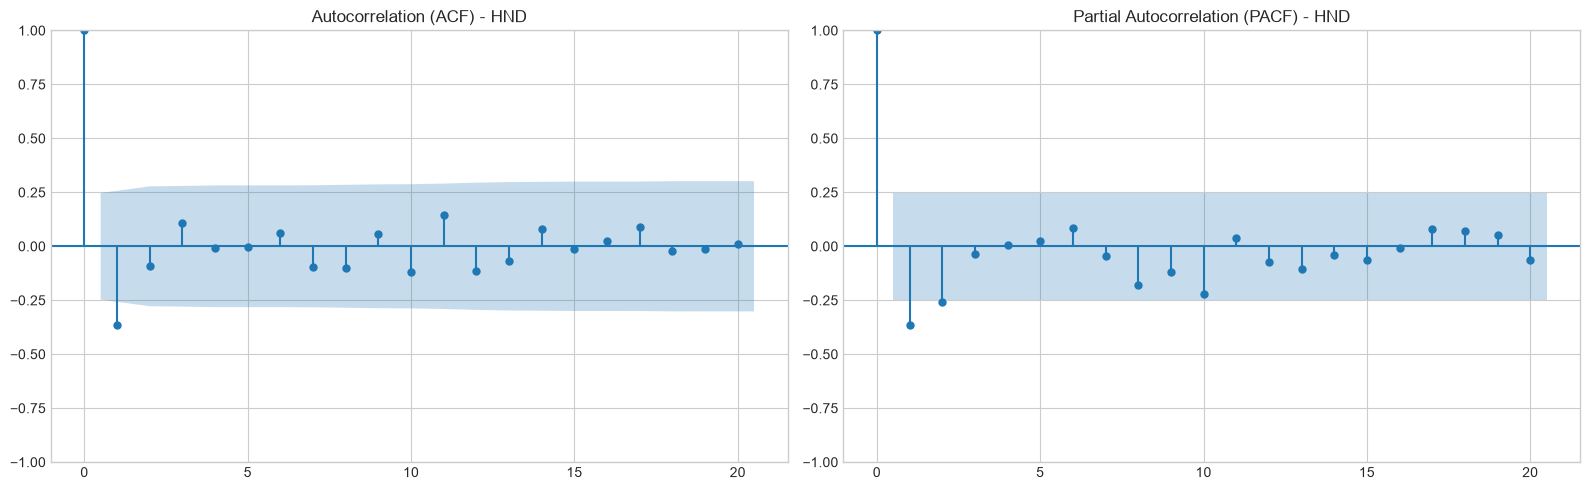

In [5]:
# Pick a specific country to analyze (you can change this to 'BRA', 'MEX', etc.)
target_country = 'HND'
series = ts_data_clean[target_country]
# Apply differencing if the ADF test deemed it necessary
if integration_orders[target_country] > 0:
    series = series.diff().dropna()
    print(f"Applied 1st order differencing to {target_country} before plotting.")
else:
    print(f"{target_country} is stationary. No differencing applied.")
# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(series, ax=axes[0], lags=20, title=f'Autocorrelation (ACF) - {target_country}')
plot_pacf(series, ax=axes[1], lags=20, title=f'Partial Autocorrelation (PACF) - {target_country}', method='ywm')
plt.tight_layout()
plt.show()

## Statistical Modelling (ARIMA)

We will use the pmdarima library to run an auto_arima search. This will automatically test different combinations of p and q and select the best model for each country based on the lowest Akaike Information Criterion (AIC).

--- Fitting Auto-ARIMA with Rolling Origin Validation ---
Running Rolling Origin CV for VEN...
Running Rolling Origin CV for URY...
Running Rolling Origin CV for PER...
Running Rolling Origin CV for PRY...
Running Rolling Origin CV for PAN...
Running Rolling Origin CV for NIC...
Running Rolling Origin CV for MEX...
Running Rolling Origin CV for HND...
Running Rolling Origin CV for HTI...
Running Rolling Origin CV for GTM...
Running Rolling Origin CV for SLV...
Running Rolling Origin CV for ECU...
Running Rolling Origin CV for DOM...
Running Rolling Origin CV for CUB...
Running Rolling Origin CV for CRI...
Running Rolling Origin CV for COL...
Running Rolling Origin CV for CHL...
Running Rolling Origin CV for BRA...
Running Rolling Origin CV for BOL...
Running Rolling Origin CV for ARG...

--- Rolling Origin CV Evaluation Metrics ---


,"ARIMA Order (p,d,q)",RMSE,MAE
PRY,"(1, 0, 0)",2.754599,2.482272
BRA,"(1, 1, 1)",3.370064,2.552824
HTI,"(0, 0, 0)",4.066107,3.944273
GTM,"(1, 0, 0)",4.247751,3.048
CRI,"(0, 0, 1)",5.101082,3.914376
NIC,"(1, 0, 2)",5.173188,3.799575
MEX,"(0, 1, 1)",5.49019,4.234444
URY,"(2, 0, 1)",5.732385,4.469897
CHL,"(1, 0, 1)",6.325836,5.353425
CUB,"(1, 0, 0)",6.650795,5.11579


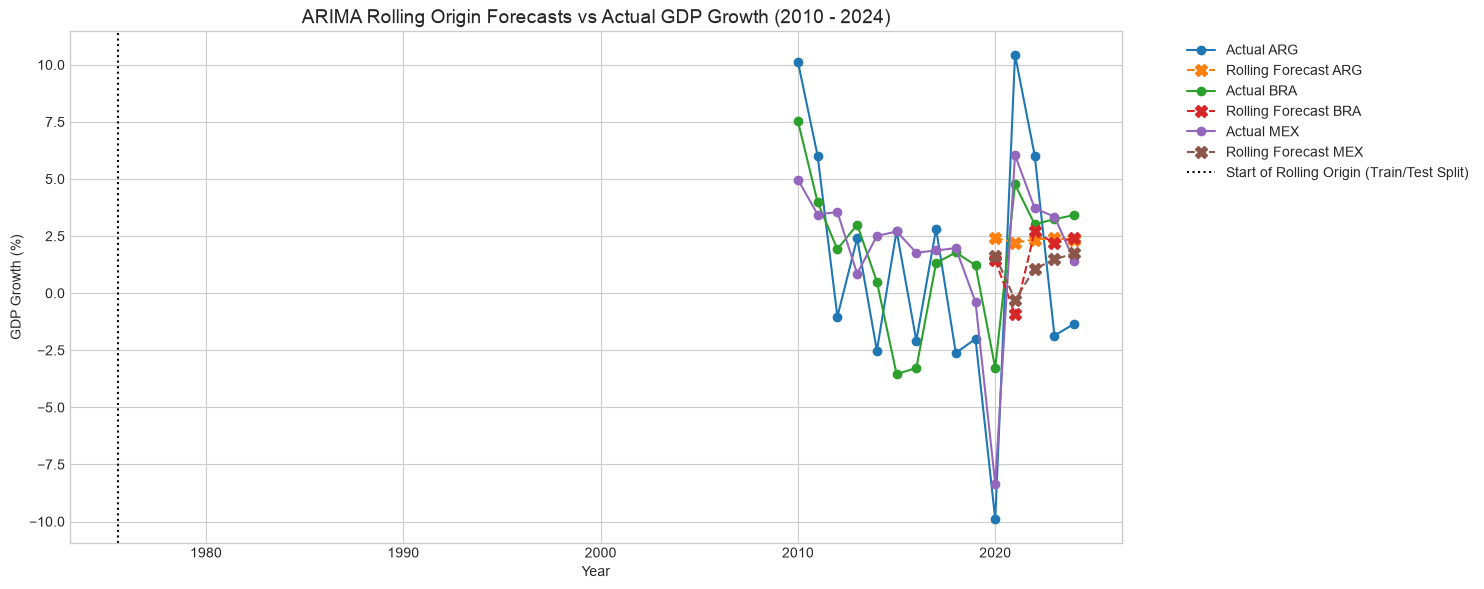

In [6]:
import pmdarima as pm
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
# 1. Define Train/Test Horizons
test_size = 5 # Years 2020 to 2024
train_data = ts_data_clean.iloc[:-test_size]
test_data = ts_data_clean.iloc[-test_size:]
# Dictionaries to store results and predictions
arima_results_cv = {}
arima_forecasts_cv = pd.DataFrame(index=test_data.index)
print("--- Fitting Auto-ARIMA with Rolling Origin Validation ---")
# 2. Loop through all 20 countries
for country in ts_data_clean.columns:
    print(f"Running Rolling Origin CV for {country}...")

    # Initial fit on the training set (1961 - 2019)
    model = pm.auto_arima(train_data[country],
                          start_p=0, start_q=0,
                          max_p=4, max_q=4,
                          d=None,
                          seasonal=False,
                          trace=False,
                          error_action='ignore',
                          suppress_warnings=True,
                          stepwise=True)

    rolling_forecasts = []

    # 3. Walk-Forward (Rolling Origin) Loop for the 5 test years
    for i in range(len(test_data)):
        # Predict exactly 1 step ahead (FIX: Using np.asarray to handle both Series and Arrays safely)
        prediction = model.predict(n_periods=1)
        pred_value = np.asarray(prediction)[0]
        rolling_forecasts.append(pred_value)

        # Get the actual observation that just "occurred"
        actual_obs = test_data[country].iloc[i]

        # Update the model with the new observation before predicting the next year
        model.update(actual_obs)

    arima_forecasts_cv[country] = rolling_forecasts

    # 4. Calculate Evaluation Metrics
    rmse = np.sqrt(mean_squared_error(test_data[country], rolling_forecasts))
    mae = mean_absolute_error(test_data[country], rolling_forecasts)

    # Store results
    arima_results_cv[country] = {
        'ARIMA Order (p,d,q)': model.order,
        'RMSE': rmse,
        'MAE': mae
    }
# 5. Display the final metrics sorted by RMSE
baseline_metrics_cv_df = pd.DataFrame(arima_results_cv).T
print("\n--- Rolling Origin CV Evaluation Metrics ---")
display(baseline_metrics_cv_df.sort_values(by='RMSE'))
     

# Select a few countries to visualize the rolling forecast vs actuals
countries_to_plot = ['ARG', 'BRA', 'MEX']
plt.figure(figsize=(15, 6))
for country in countries_to_plot:
    # Plot Actuals
    plt.plot(ts_data_clean.index[-15:], ts_data_clean[country].iloc[-15:],
             label=f'Actual {country}', marker='o')

    # Plot Rolling Origin Forecasts
    plt.plot(test_data.index, arima_forecasts_cv[country],
             label=f'Rolling Forecast {country}', linestyle='--', marker='X', markersize=8)
plt.title('ARIMA Rolling Origin Forecasts vs Actual GDP Growth (2010 - 2024)', fontsize=14)
plt.axvline(x=2019.5, color='black', linestyle=':', label='Start of Rolling Origin (Train/Test Split)')
plt.ylabel('GDP Growth (%)')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

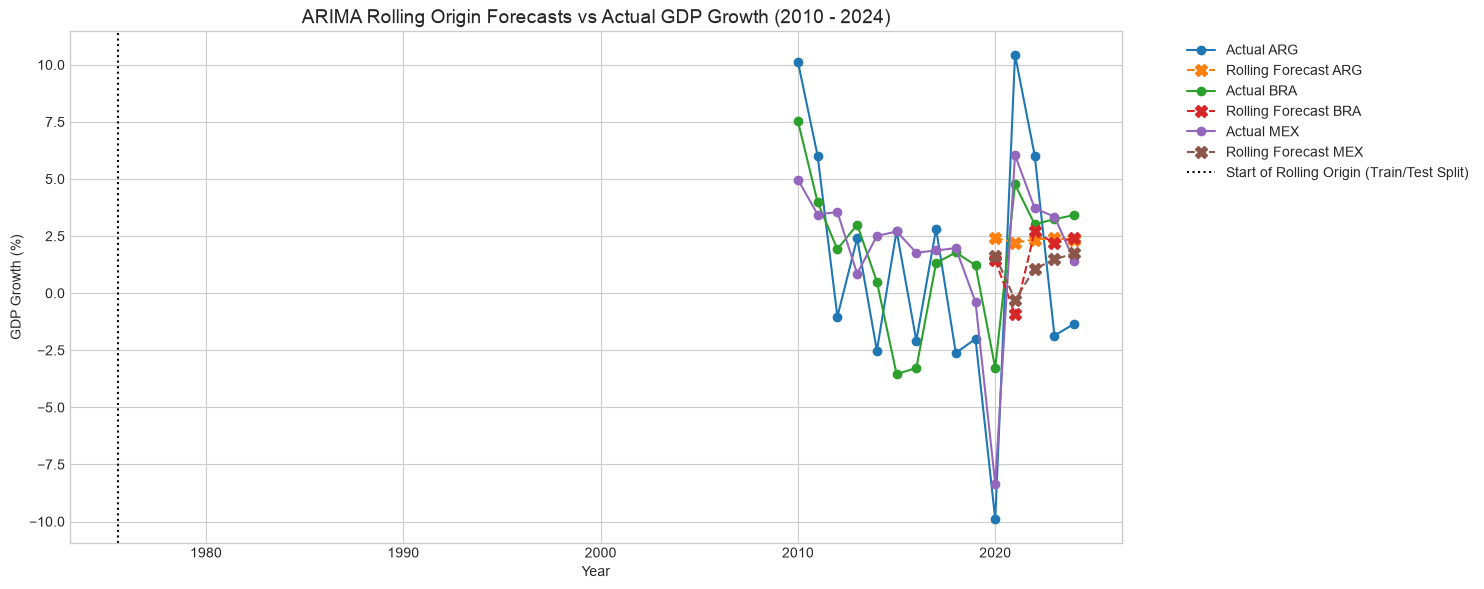

In [7]:
# Select a few countries to visualize the rolling forecast vs actuals
countries_to_plot = ['ARG', 'BRA', 'MEX']
plt.figure(figsize=(15, 6))
for country in countries_to_plot:
    # Plot Actuals
    plt.plot(ts_data_clean.index[-15:], ts_data_clean[country].iloc[-15:],
             label=f'Actual {country}', marker='o')

    # Plot Rolling Origin Forecasts
    plt.plot(test_data.index, arima_forecasts_cv[country],
             label=f'Rolling Forecast {country}', linestyle='--', marker='X', markersize=8)
plt.title('ARIMA Rolling Origin Forecasts vs Actual GDP Growth (2010 - 2024)', fontsize=14)
plt.axvline(x=2019.5, color='black', linestyle=':', label='Start of Rolling Origin (Train/Test Split)')
plt.ylabel('GDP Growth (%)')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Machine Learning Modelling

### 1. XGBoost

Instead of fitting 20 isolated local models, we are going to build a Global Supervised Model using an ensemble tree algorithm (we'll use XGBoost).

To do this, we need to completely restructure our dataset:
- **Long Format (Panel Data):** We will stack all countries into a single dataset.
- **Feature Engineering:** Machine learning models don't naturally "understand" time. We have to create explicit lag features (e.g., GDP of t−1, t−2, t−3) so the model can look at the recent past to predict the future.
- **Global Learning:** By pooling the data, the model learns regional interactions. For instance, it can learn how a shock in larger economies might correlate with trends across the rest of the continent.

In [8]:
%pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
# 1. Prepare Panel Data (Convert to Long Format)
long_df = ts_data_clean.reset_index().rename(columns={'index': 'Year'})
# FIX 1: Extract just the integer year from the DateTime objects
long_df['Year'] = long_df['Year'].dt.year
long_df = long_df.melt(id_vars=['Year'], var_name='Country', value_name='GDP_Growth')
# Sort to ensure chronological order per country
long_df = long_df.sort_values(['Country', 'Year']).reset_index(drop=True)
# 2. Feature Engineering: Create Lag Features
num_lags = 3 # We will use the past 3 years to predict the current year
for i in range(1, num_lags + 1):
    long_df[f'Lag_{i}'] = long_df.groupby('Country')['GDP_Growth'].shift(i)
# Drop the first 3 years per country since they now have NaN lags
panel_df = long_df.dropna().reset_index(drop=True)
# 3. Rolling Origin CV Setup
test_years = [2020, 2021, 2022, 2023, 2024]
xgb_forecasts_cv = pd.DataFrame(index=test_years, columns=ts_data_clean.columns)
print("--- Training Global XGBoost Model with Rolling Origin CV ---")
for year in test_years:
    print(f"Training up to {year-1}, predicting {year}...")

    # Train set: All data strictly BEFORE the current test year
    train_df = panel_df[panel_df['Year'] < year]
    # Test set: Exactly the current test year
    test_df = panel_df[panel_df['Year'] == year]

    # Extract Features (X) and Target (y)
    X_train = pd.get_dummies(train_df.drop(columns=['Year', 'GDP_Growth']), columns=['Country'])
    y_train = train_df['GDP_Growth']

    X_test = pd.get_dummies(test_df.drop(columns=['Year', 'GDP_Growth']), columns=['Country'])

    # Align columns to ensure the test set has exactly the same features as the train set
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

    # Initialize and Train the Model
    xgb_model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    xgb_model.fit(X_train, y_train)

    # Predict for all 20 countries simultaneously
    preds = xgb_model.predict(X_test)

    # Store predictions dynamically
    for i, country in enumerate(test_df['Country'].values):
        xgb_forecasts_cv.at[year, country] = preds[i]
# 4. Calculate Final Evaluation Metrics
xgb_results = {}
# FIX 2: Convert the integer test years back into DateTime objects to query the actuals correctly
test_dates = pd.to_datetime([str(y) for y in test_years])
for country in ts_data_clean.columns:
    actuals = ts_data_clean.loc[test_dates, country]
    preds = xgb_forecasts_cv[country].astype(float)

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)

    xgb_results[country] = {'RMSE': rmse, 'MAE': mae}
# Display metrics alongside ARIMA for comparison
xgb_metrics_df = pd.DataFrame(xgb_results).T
print("\n--- XGBoost Rolling CV Evaluation Metrics ---")
display(xgb_metrics_df.sort_values(by='RMSE'))

--- Training Global XGBoost Model with Rolling Origin CV ---
Training up to 2019, predicting 2020...
Training up to 2020, predicting 2021...
Training up to 2021, predicting 2022...
Training up to 2022, predicting 2023...
Training up to 2023, predicting 2024...

--- XGBoost Rolling CV Evaluation Metrics ---


,RMSE,MAE
HTI,2.609896,2.182172
PRY,2.706836,2.401860
BRA,3.484608,2.476293
GTM,4.568044,3.215838
CRI,4.961452,3.731882
MEX,5.666929,4.366974
NIC,5.790432,3.632499
URY,5.889781,4.962498
CUB,6.220770,4.471317
CHL,6.541018,5.334062


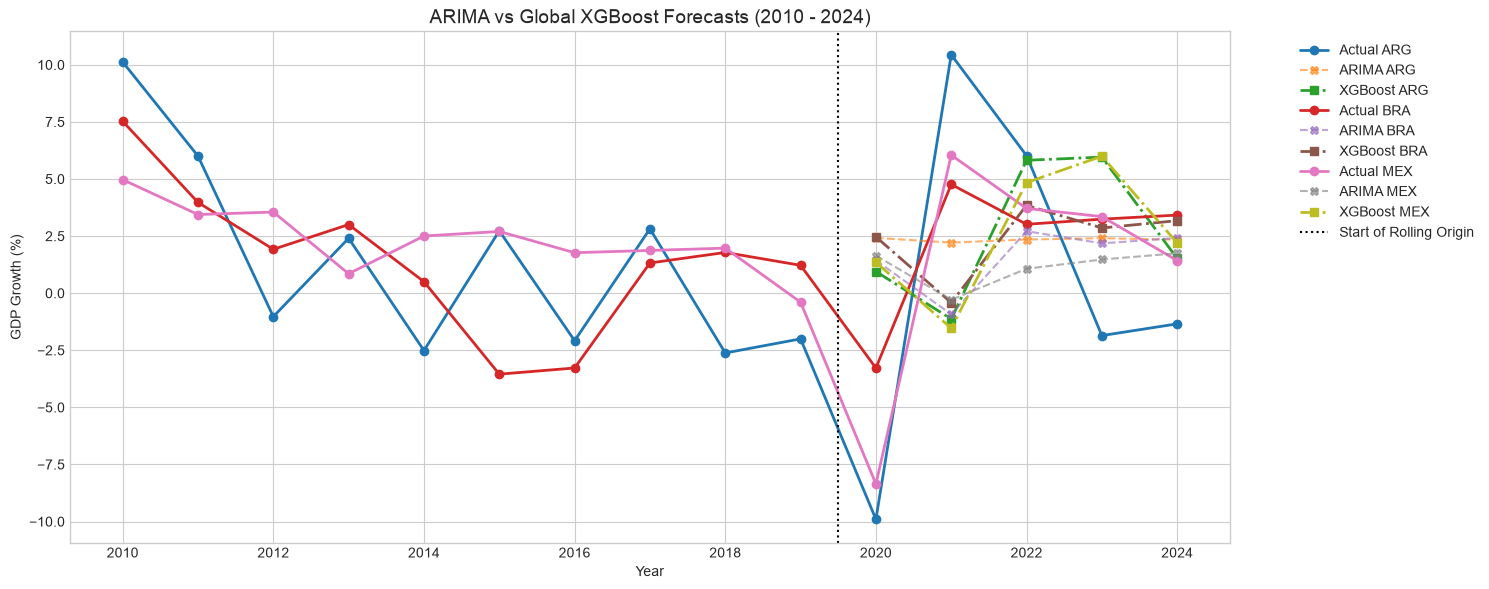

In [10]:
countries_to_plot = ['ARG', 'BRA', 'MEX']
plt.figure(figsize=(15, 6))
for country in countries_to_plot:
    # Actual Data (Extract integer years for the x-axis)
    actual_years = ts_data_clean.index[-15:].year
    plt.plot(actual_years, ts_data_clean[country].iloc[-15:],
             label=f'Actual {country}', marker='o', linewidth=2)

    # ARIMA Forecast (from Phase 2)
    plt.plot(test_years, arima_forecasts_cv[country],
             label=f'ARIMA {country}', linestyle='--', marker='X', alpha=0.6)

    # XGBoost Forecast
    plt.plot(test_years, xgb_forecasts_cv[country],
             label=f'XGBoost {country}', linestyle='-.', marker='s', linewidth=2)
plt.title('ARIMA vs Global XGBoost Forecasts (2010 - 2024)', fontsize=14)
plt.axvline(x=2019.5, color='black', linestyle=':', label='Start of Rolling Origin')
plt.ylabel('GDP Growth (%)')
plt.xlabel('Year')
# Clean up legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 2. Random Forest

While XGBoost builds trees sequentially to correct previous errors (which can sometimes overfit noisy macro data), Random Forest builds independent trees and averages them, which makes it exceptionally robust against variance.

Since we already set up the panel data pipeline, we can swap the algorithm seamlessly while maintaining the exact same Rolling Origin Cross-Validation framework to ensure the RMSE scores are perfectly comparable.

In [11]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
# 1. Prepare Panel Data (We'll recreate it just to ensure the environment is fresh)
long_df = ts_data_clean.reset_index().rename(columns={'index': 'Year'})
long_df['Year'] = long_df['Year'].dt.year
long_df = long_df.melt(id_vars=['Year'], var_name='Country', value_name='GDP_Growth')
long_df = long_df.sort_values(['Country', 'Year']).reset_index(drop=True)
# Feature Engineering: 3-year lags
num_lags = 3
for i in range(1, num_lags + 1):
    long_df[f'Lag_{i}'] = long_df.groupby('Country')['GDP_Growth'].shift(i)
panel_df = long_df.dropna().reset_index(drop=True)
# 2. Rolling Origin CV Setup
test_years = [2020, 2021, 2022, 2023, 2024]
rf_forecasts_cv = pd.DataFrame(index=test_years, columns=ts_data_clean.columns)
print("--- Training Global Random Forest Model with Rolling Origin CV ---")
for year in test_years:
    print(f"Training up to {year-1}, predicting {year}...")

    train_df = panel_df[panel_df['Year'] < year]
    test_df = panel_df[panel_df['Year'] == year]

    X_train = pd.get_dummies(train_df.drop(columns=['Year', 'GDP_Growth']), columns=['Country'])
    y_train = train_df['GDP_Growth']

    X_test = pd.get_dummies(test_df.drop(columns=['Year', 'GDP_Growth']), columns=['Country'])
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

    # Initialize and Train Random Forest
    # max_depth=5 helps prevent individual trees from memorizing the noise in the panel data
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)

    preds = rf_model.predict(X_test)

    for i, country in enumerate(test_df['Country'].values):
        rf_forecasts_cv.at[year, country] = preds[i]
# 3. Calculate Final Evaluation Metrics
rf_results = {}
test_dates = pd.to_datetime([str(y) for y in test_years])
for country in ts_data_clean.columns:
    actuals = ts_data_clean.loc[test_dates, country]
    preds = rf_forecasts_cv[country].astype(float)

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)

    rf_results[country] = {'RMSE': rmse, 'MAE': mae}
# Display metrics
rf_metrics_df = pd.DataFrame(rf_results).T
print("\n--- Random Forest Rolling CV Evaluation Metrics ---")
display(rf_metrics_df.sort_values(by='RMSE'))

--- Training Global Random Forest Model with Rolling Origin CV ---
Training up to 2019, predicting 2020...
Training up to 2020, predicting 2021...
Training up to 2021, predicting 2022...
Training up to 2022, predicting 2023...
Training up to 2023, predicting 2024...

--- Random Forest Rolling CV Evaluation Metrics ---


,RMSE,MAE
PRY,2.879918,2.573818
HTI,3.301099,3.115276
BRA,3.430577,2.672770
GTM,4.067658,2.891398
CRI,4.759560,3.393933
NIC,4.985746,3.502859
URY,5.188294,3.927466
MEX,5.386536,3.849317
CUB,5.880521,4.296736
CHL,6.359344,5.159744


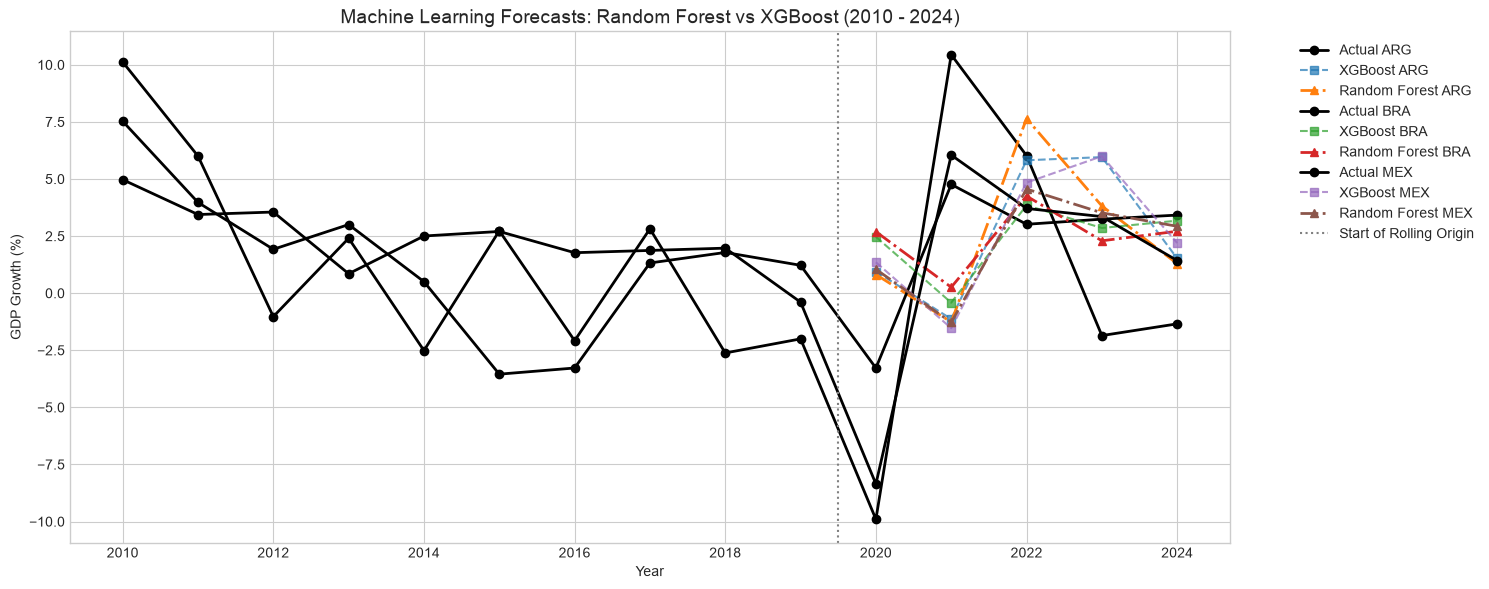

In [12]:
countries_to_plot = ['ARG', 'BRA', 'MEX']
plt.figure(figsize=(15, 6))
for country in countries_to_plot:
    # Actual Data
    actual_years = ts_data_clean.index[-15:].year
    plt.plot(actual_years, ts_data_clean[country].iloc[-15:],
             label=f'Actual {country}', marker='o', linewidth=2, color='black')

    # XGBoost Forecast (From previous step)
    plt.plot(test_years, xgb_forecasts_cv[country],
             label=f'XGBoost {country}', linestyle='--', marker='s', alpha=0.7)

    # Random Forest Forecast
    plt.plot(test_years, rf_forecasts_cv[country],
             label=f'Random Forest {country}', linestyle='-.', marker='^', linewidth=2)
plt.title('Machine Learning Forecasts: Random Forest vs XGBoost (2010 - 2024)', fontsize=14)
plt.axvline(x=2019.5, color='gray', linestyle=':', label='Start of Rolling Origin')
plt.ylabel('GDP Growth (%)')
plt.xlabel('Year')
# Clean up legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Functional Time Series (imported results from independent script) and Diedbold-Mariano test

In [17]:
import numpy as np
import pandas as pd
from scipy.stats import norm
def diebold_mariano_test(actual, pred1, pred2, h=1):
    """
    Computes the Diebold-Mariano test statistic.
    Null Hypothesis: Two forecasts have the same accuracy.
    """
    actual = np.asarray(actual)
    pred1 = np.asarray(pred1)
    pred2 = np.asarray(pred2)

    # Calculate forecast errors
    e1 = actual - pred1
    e2 = actual - pred2

    # Calculate loss differential (using Squared Error loss)
    d = (e1 ** 2) - (e2 ** 2)
    d_bar = np.mean(d)

    N = len(d)

    # Calculate autocovariance of the loss differential
    gamma = np.zeros(h)
    for i in range(h):
        gamma[i] = np.sum((d[i:] - d_bar) * (d[:N-i] - d_bar)) / N

    # Variance of d
    var_d = gamma[0] + 2 * np.sum(gamma[1:])

    if var_d == 0:
        return 0, 1.0 # Variance is 0, cannot reject null

    # Calculate DM Statistic and p-value
    dm_stat = d_bar / np.sqrt(var_d / N)
    p_value = 2 * (1 - norm.cdf(abs(dm_stat)))

    return dm_stat, p_value

# 1. The new FAR(1) predictions you provided (2020-2024)
new_far_predictions = {
    'Venezuela': [-18.679, -17.458, -3.573, 3.216, 4.468],
    'Haiti': [-0.061, -5.753, 1.714, 0.986, 1.802],
    'Uruguay': [-0.061, -5.753, 1.714, 0.986, 1.802],
    'Argentina': [-0.668, -11.543, 4.296, 2.994, 3.223],
    'El Salvador': [1.591, -4.328, 7.109, 2.424, 4.462],
    'Nicaragua': [3.825, -8.132, 9.708, 4.871, 0.242],
    'Cuba': [1.242, -5.030, 2.620, 1.978, 2.370],
    'Bolivia': [1.242, -5.030, 2.620, 1.978, 2.370],
    'Peru': [5.520, -6.119, 7.850, 2.139, 2.793],
    'Mexico': [-0.382, -3.550, 1.396, 1.850, 5.155],
    'Ecuador': [2.894, -6.276, 5.997, 2.773, 3.927],
    'Guatemala': [2.894, -6.276, 5.997, 2.773, 3.927],
    'Brazil': [1.318, -7.242, 4.623, 2.433, 3.810],
    'Chile': [1.318, -7.242, 4.623, 2.433, 3.810],
    'Colombia': [1.318, -7.242, 4.623, 2.433, 3.810],
    'Costa Rica': [2.846, -6.783, 7.209, 3.159, 4.034],
    'Paraguay': [2.846, -6.783, 7.209, 3.159, 4.034],
    'Dominican Republic': [4.752, -11.277, 7.050, 4.601, 6.084],
    'Panama': [4.752, -11.277, 7.050, 4.601, 6.084],
    'Honduras': [4.752, -11.277, 7.050, 4.601, 6.084]
}

# 2. Compile global arrays using your notebook's existing variables
print("--- Running Updated Diebold-Mariano Tests ---")

global_actuals = []
global_arima = []
global_ml = [] 
global_fts = []

test_dates = pd.to_datetime([str(y) for y in test_years])

for country in ts_data_clean.columns:
    # Ensure country name mapping matches exactly. 
    # If your df uses "Venezuela" instead of "Venezuela, RB", adjust the dict key above!
    country_key = country 
    
    global_actuals.extend(ts_data_clean.loc[test_dates, country].values)
    global_arima.extend(arima_forecasts_cv[country].values)
    
    # Using rf_forecasts_cv here; change to xgb_forecasts_cv if needed
    global_ml.extend(rf_forecasts_cv[country].values)
    
    # Append the new FAR(1) predictions
    country_name_map = {
        'VEN': 'Venezuela',
        'URY': 'Uruguay',
        'PER': 'Peru',
        'PRY': 'Paraguay',
        'PAN': 'Panama',
        'NIC': 'Nicaragua',
        'MEX': 'Mexico',
        'HND': 'Honduras',
        'HTI': 'Haiti',
        'GTM': 'Guatemala',
        'SLV': 'El Salvador',
        'ECU': 'Ecuador',
        'DOM': 'Dominican Republic',
        'CUB': 'Cuba',
        'CRI': 'Costa Rica',
        'COL': 'Colombia',
        'CHL': 'Chile',
        'BRA': 'Brazil',
        'BOL': 'Bolivia',
        'ARG': 'Argentina'
    }
    country_key = country_name_map.get(country, country)
    global_fts.extend(new_far_predictions[country_key])

# 3. Run the tests using your existing diebold_mariano_test function
# 1. ARIMA vs Machine Learning
dm_stat_1, p_val_1 = diebold_mariano_test(global_actuals, global_arima, global_ml)
# 2. ARIMA vs Functional Time Series
dm_stat_2, p_val_2 = diebold_mariano_test(global_actuals, global_arima, global_fts)
# 3. Machine Learning vs Functional Time Series
dm_stat_3, p_val_3 = diebold_mariano_test(global_actuals, global_ml, global_fts)

# 4. Compile the final report
dm_results = pd.DataFrame({
    'Comparison': [
        'ARIMA vs Machine Learning',
        'ARIMA vs Wavelet FTS (FAR)',
        'Machine Learning vs Wavelet FTS (FAR)'
    ],
    'DM Statistic': [dm_stat_1, dm_stat_2, dm_stat_3],
    'P-Value': [p_val_1, p_val_2, p_val_3]
})

def interpret_dm(row):
    model_1, model_2 = row['Comparison'].split(' vs ')
    if row['P-Value'] > 0.05:
        return "No statistical difference in accuracy"
    elif row['DM Statistic'] > 0:
        return f"{model_2} is significantly better"
    else:
        return f"{model_1} is significantly better"

dm_results['Conclusion'] = dm_results.apply(interpret_dm, axis=1)
display(dm_results)

--- Running Updated Diebold-Mariano Tests ---


,Comparison,DM Statistic,P-Value,Conclusion
0,ARIMA vs Machine Learning,2.566614,0.010270,Machine Learning is significantly better
1,ARIMA vs Wavelet FTS (FAR),-1.889510,0.058824,No statistical difference in accuracy
2,Machine Learning vs Wavelet FTS (FAR),-3.250170,0.001153,Machine Learning is significantly better
